In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

# Basic Classification Algorithms
In this notebook, we demonstrate basic time series classification algorithms using sktime only.

In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

In [1]:
from sktime.datasets import load_UCR_UEA_dataset
import numpy as np

# Load GunPoint from UCR/UEA via sktime
X_train, y_train = load_UCR_UEA_dataset(name="GunPoint", split="train", return_type="numpy3D")
X_test, y_test = load_UCR_UEA_dataset(name="GunPoint", split="test", return_type="numpy3D")

# Combine for quick visualization only
X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)
num_classes = len(set(y))
n_timesteps = X.shape[2]
X.shape, y.shape, n_timesteps, num_classes

((200, 1, 150), (200,), 150, 2)

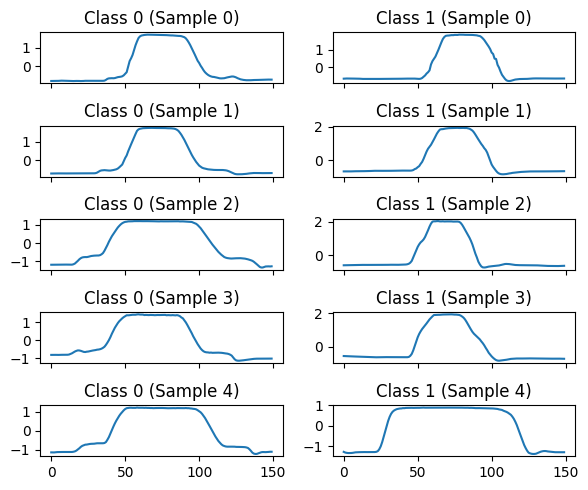

In [2]:
# Show some examples of each class
import matplotlib.pyplot as plt

fig, ax = plt.subplots(5, num_classes, figsize=(num_classes * 3.0, 5), sharex=True)
for i in range(num_classes):
    for j in range(5):
          ax[j, i].plot(X[y == sorted(set(y))[i]][j, 0, :].ravel())
          ax[j, i].set_title(f'Class {i} (Sample {j})')
fig.tight_layout()

In [3]:
# k-NN Classifier (Euclidean & DTW distance)
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier

# Configure Distance Method (euclidean for Euclidean and dtw for DTW)
# method = 'euclidean'
method = 'dtw'

knn = KNeighborsTimeSeriesClassifier(n_neighbors=10, distance=method)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = np.mean(y_test == y_pred)
print(f"kNN Accuracy (with {method} Distance): {accuracy:.2f}")

kNN Accuracy (with dtw Distance): 0.79


In [4]:
# Decision Tree Classifier
from sktime.classification.sklearn import ContinuousIntervalTree
dt_clf = ContinuousIntervalTree(max_depth=10, random_state=42)
dt_clf.fit(X_train, y_train)
y_pred = dt_clf.predict(X_test)

accuracy = np.mean(y_test == y_pred)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Decision Tree Accuracy: 0.85


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [5]:
# Random Forest Classifier
from sktime.classification.interval_based import TimeSeriesForestClassifier
rf_clf = TimeSeriesForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

accuracy = np.mean(y_test == y_pred)
print(f"Random Forest Accuracy: {accuracy:.2f}")

Random Forest Accuracy: 0.95


In [9]:
# Rotation Forest Classifier (sktime wrapper)
from sktime.classification.sklearn import RotationForest

# RotationForest is a vector classifier: convert panel data to 2D features
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

rotf = RotationForest(n_estimators=50, random_state=42)
rotf.fit(X_train_2d, y_train)
y_pred = rotf.predict(X_test_2d)

accuracy = np.mean(y_test == y_pred)
print(f"Rotation Forest Accuracy: {accuracy:.2f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Rotation Forest Accuracy: 0.93


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
# DrCIF Classifier
from sktime.classification.interval_based import DrCIF

drcif = DrCIF(n_estimators=100, random_state=42)
drcif.fit(X_train, y_train)
y_pred = drcif.predict(X_test)

accuracy = np.mean(y_test == y_pred)
print(f"DrCIF Accuracy: {accuracy:.2f}")